Import Libraries

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [66]:
df = pd.read_csv("../data/labeled_data.csv")

df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


Class Distribution

In [67]:
df['class'].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

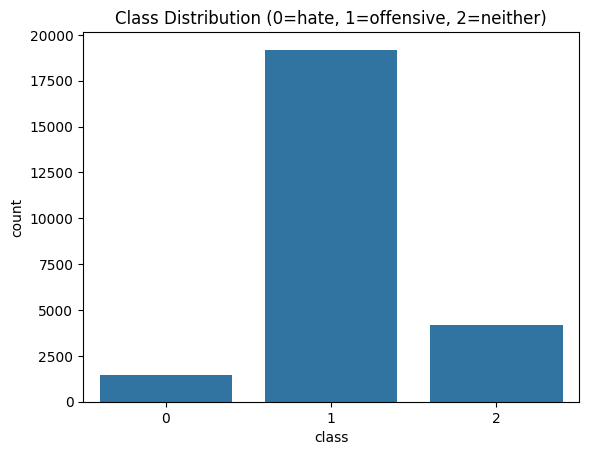

In [68]:
sns.countplot(x='class', data=df)
plt.title("Class Distribution (0=hate, 1=offensive, 2=neither)")
plt.show()

Text Length Analysis

In [69]:
df['length'] = df['tweet'].apply(len)

df['length'].describe()

count    24783.000000
mean        85.523625
std         41.646293
min          5.000000
25%         52.000000
50%         81.000000
75%        119.000000
max        756.000000
Name: length, dtype: float64

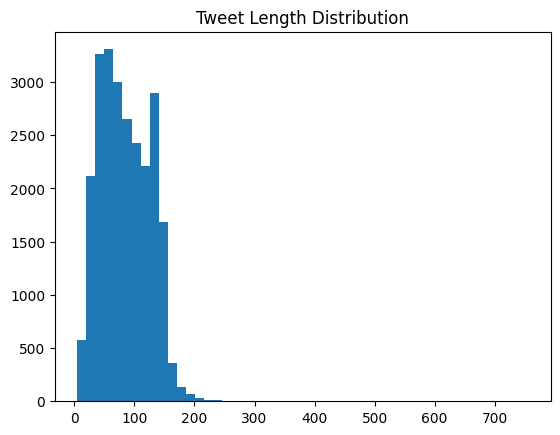

In [70]:
plt.hist(df['length'], bins=50)
plt.title("Tweet Length Distribution")
plt.show()

Show Examples From Each Class

In [71]:
for c in df['class'].unique():
    print("\nClass:", c)
    print(df[df['class']==c]['tweet'].sample(3).values)


Class: 2
<StringArray>
['Other Jihadi news #ISIS executed #Kuwait preacher Redha Lari coz he was..&#8220;too extreme&#8221; &amp; hampered reconciliation with Nusra with his fatwas',
                                                           'Ok so not all the shows on Cartoon Network are complete trash. Stevm Universe is awwwwwesomeeeeee',
                                                                                                                                         'Anglo-Saxon Mike Oz']
Length: 3, dtype: str

Class: 1
<StringArray>
['My car so wet My bitch so wet when I drive i car pool',
     'Aint this a bitch,! The power out from this shit.',
                              'Frankie is a twat. #BB16']
Length: 3, dtype: str

Class: 0
<StringArray>
['From now on, I will call all radical MUSLIMS niggers!\r\nIt is very fitting, and it is racist! \r\nI AM RACIST AGAINST ANYONE WHO HATES AMERICA!',
                                                                                 

Text Cleaning

In [ ]:
import re
# use regular expression for text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE) # remove URLs
    text = re.sub(r"@\w+", "", text) # remove @
    text = re.sub(r"#", "", text) # remove hashtag but keep the word
    text = re.sub(r"[^a-z\s!?.]", "", text) # remove that are not letters but keep basic punctuations to capture tone
    text = " ".join(text.split()) # remove double white spaces
    return text

df['clean_tweet'] = df['tweet'].apply(clean_text)

In [73]:
X = df['clean_tweet']
y = df['class']


df_cleaned = pd.concat([X, y], axis=1)
print(f"Number of NaN values: {df_cleaned.isna().sum()}")

df_cleaned.head()

Number of NaN values: clean_tweet    1
class          0
dtype: int64


,clean_tweet,class
0,!!! rt as a woman you shouldnt complain about ...,2
1,!!!!! rt boy dats cold...tyga dwn bad for cuff...,1
2,!!!!!!! rt dawg!!!! rt you ever fuck a bitch a...,1
3,!!!!!!!!! rt she look like a tranny,1
4,!!!!!!!!!!!!! rt the shit you hear about me mi...,1


In [74]:
for c in df['class'].unique(): # 0=hate, 1=offensive, 2=neither
    
    if c == 0:
        print("\nClass:", c , "(hate)") 
    elif c == 1:
        print("\nClass:", c , "(offensive)") 
    else:
        print("\nClass:", c , "(neither)") 
    print(df[df['class']==c]['clean_tweet'].sample(3).values)


Class: 2 (neither)
<StringArray>
[                                       'for two year old oreos?',
         'rt yo mama so ghetto she uses cigarette butts as qtips',
 'mark teixeira finally stepping up hr and couple of bbs yankees']
Length: 3, dtype: str

Class: 1 (offensive)
<StringArray>
[                                  'no bitch i did not want to wear makeup',
                                                 'my main bitch is a ghost',
 'i would have loved to watch newman bitch slap johnson id pay to see that']
Length: 3, dtype: str

Class: 0 (hate)
<StringArray>
['rt fucking chinks in clash of clans always fuck me up. bitch ass kamikaze faggots.',
                                       'hell naw fuck them bitches serves them right',
                                          'i hear bill likes trailer trash like you.']
Length: 3, dtype: str


In [75]:
df_cleaned.to_csv('../data/data_cleaned.csv', index=False)
print("data_cleaned saved.")

data_cleaned saved.
